# 🚀 ML Pipeline: Przewidywanie Zużycia Paliwa (MPG)

**Problem:** Regresja - przewidujemy wartość ciągłą (`mpg`).
**Stack:** Pandas, Plotly Express, XGBoost.

### Słownik danych (Specyfikacja techniczna):
*   **mpg** – **Mile na galonie** – Target (cel). Wydajność paliwowa.
*   **cylinders** – **Cylindry** – Liczba cylindrów (4, 6, 8). Rozmiar hardware'u.
*   **displacement** – **Pojemność skokowa**
*   **horsepower** – **Konie mechaniczne**
*   **weight** – **Masa** – Waga auta w funtach (lbs)
*   **acceleration** – **Przyspieszenie** - (0-60 mph).
*   **model_year** – **Rocznik** 
*   **origin** – **Pochodzenie** -  (USA, Europa, Japonia).

# EDA - Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import xgboost as xgb

df = sns.load_dataset('mpg').dropna()
print(f"Załadowano {len(df)} rekordów.")
df.head()

Załadowano 392 rekordów.


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


### Wizualizacja 1: Waga a Wydajność

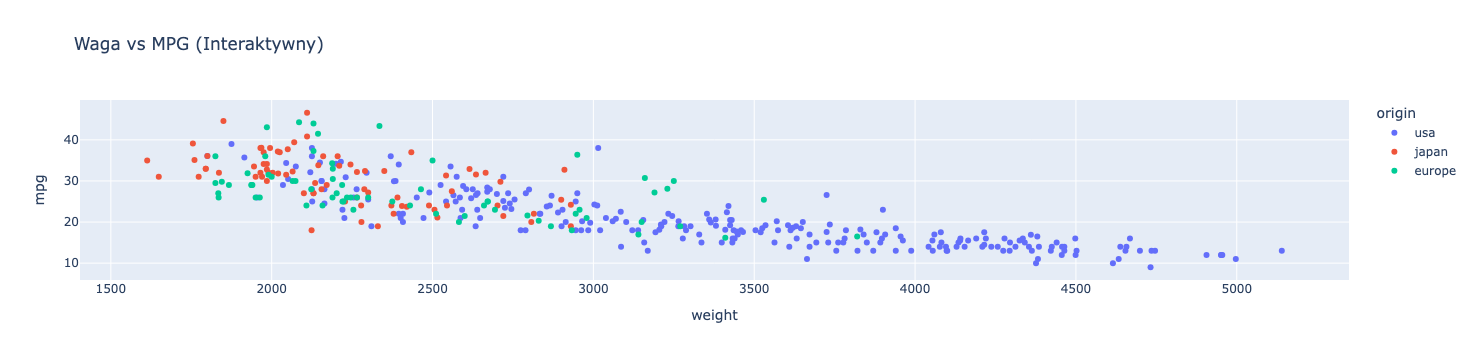

In [2]:
fig = px.scatter(df, x="weight", y="mpg", color="origin", 
                 hover_name="name", 
                 title="Waga vs MPG (Interaktywny)")
fig.show()

### 🎯 ZADANIE 1: Rozkład Targetu
Sprawdź rozkład zmiennej `mpg` przy użyciu `px.histogram`. 

In [3]:
print("Tu wpisz kod histogramu...")

Tu wpisz kod histogramu...


### 🎯 ZADANIE 2: Pochodzenie a Technologia
Użyj `px.box`, aby porównać `horsepower` w zależności od `origin`.

In [4]:
print("Tu wpisz kod boxplota...")

Tu wpisz kod boxplota...


# 2. Feature Engineering

In [5]:
# Cecha 1: Moc na wagę (Power-to-weight ratio)
df['hp_per_weight'] = df['horsepower'] / df['weight']

# Cecha 2: Wiek (bez magicznych liczb)
reference_year = df['model_year'].max()
df['car_age'] = reference_year - df['model_year']

### 🎯 ZADANIE 3: Efektywność cylindra
Stwórz cechę `disp_per_cyl` (pojemność skokowa na jeden cylinder). 

In [7]:
print("Tu stwórz nową kolumnę...")

Tu stwórz nową kolumnę...


### Train/Test Split

In [8]:
features = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 
            'hp_per_weight', 'car_age', 'origin']

X = df[features].copy()
y = df['mpg']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Model Training i Krzywa Uczenia

In [9]:
# Kodowanie kategoryczne
X_train_encoded = pd.get_dummies(X_train, columns=['origin'])
X_test_encoded = pd.get_dummies(X_test, columns=['origin']).reindex(columns=X_train_encoded.columns, fill_value=0)

# Inicjalizacja modelu
model = xgb.XGBRegressor(
    max_depth=3, 
    n_estimators=30, 
    learning_rate=0.1, 
    random_state=42,
    eval_metric="mae"
)

# Trening z monitorowaniem krzywej uczenia
model.fit(
    X_train_encoded.values, y_train,
    eval_set=[(X_train_encoded.values, y_train), (X_test_encoded.values, y_test)],
    verbose=False
)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

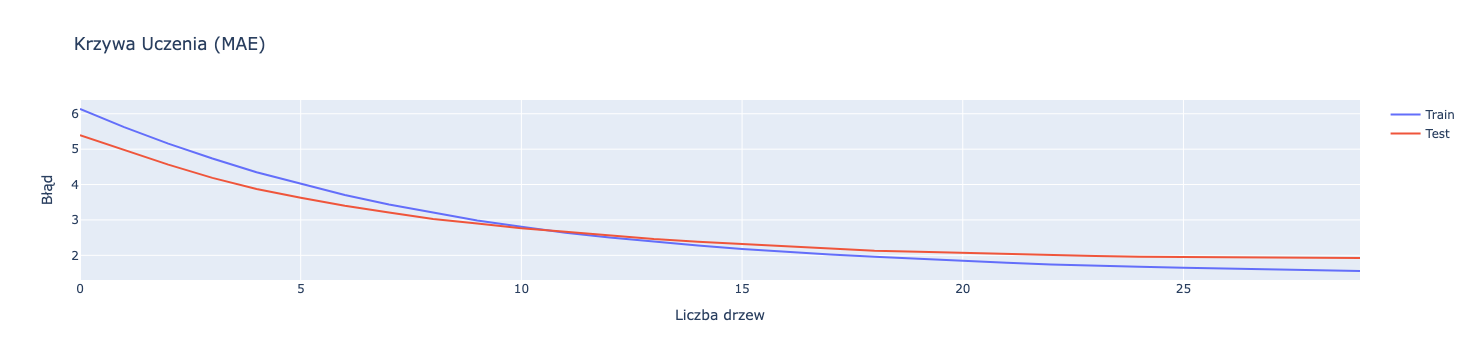

In [10]:
# Wizualizacja Krzywej Uczenia
results = model.evals_result()
fig = go.Figure()
fig.add_trace(go.Scatter(y=results['validation_0']['mae'], name='Train'))
fig.add_trace(go.Scatter(y=results['validation_1']['mae'], name='Test'))
fig.update_layout(title="Krzywa Uczenia (MAE)", xaxis_title="Liczba drzew", yaxis_title="Błąd")
fig.show()

# 4. Ewaluacja: Bias-Variance Tradeoff

MAPE Train: 6.88%
MAPE Test: 8.81%


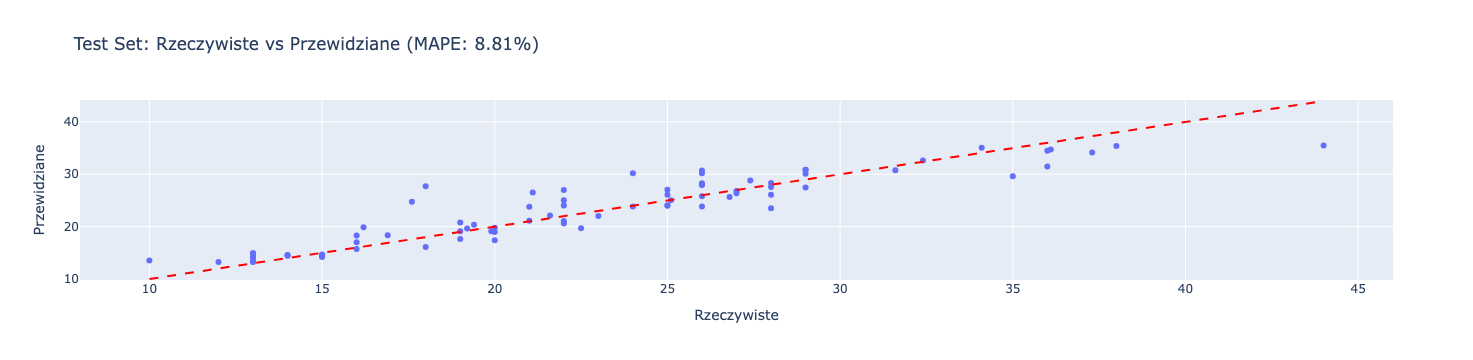

In [11]:
y_pred_train = model.predict(X_train_encoded.values)
y_pred_test = model.predict(X_test_encoded.values)

mape_train = mean_absolute_percentage_error(y_train, y_pred_train)
mape_test = mean_absolute_percentage_error(y_test, y_pred_test)

print(f"MAPE Train: {mape_train:.2%}")
print(f"MAPE Test: {mape_test:.2%}")

# Wniosek
diff = mape_test - mape_train


# Wizualizacja błędu
eval_df = pd.DataFrame({'Rzeczywiste': y_test, 'Przewidziane': y_pred_test})
fig = px.scatter(eval_df, x="Rzeczywiste", y="Przewidziane", 
                 title=f"Test Set: Rzeczywiste vs Przewidziane (MAPE: {mape_test:.2%})")
fig.add_shape(type="line", x0=y_test.min(), y0=y_test.min(), x1=y_test.max(), y1=y_test.max(), 
              line=dict(color="Red", dash="dash"))
fig.show()

### 🎯 ZADANIE: Eksperyment
Zmień `max_depth` na **15** w sekcji 3 i zobacz, co stanie się z krzywą uczenia oraz różnicą między Train a Test.